# Data Loading

In [1]:
# import required libraries for data analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
TrainData = pd.read_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/TrainDataV1.csv')
TrainData.columns = TrainData.columns.map(str.lower)
TrainData.drop(['cos_lat', 'cos_lon', 'month_cos'], axis=1, inplace=True)
# TrainData.drop(['t2m_lag2', 'e_lag2', 'ro_lag2', 'tp_lag2', 'cdir_lag2', 't2m', 'e', 'ro', 'tp', 'cdir'], axis=1, inplace=True)
TrainData.head()

,t2m,e,ro,tp,cdir,month_sin,sin_lat,sin_lon,target
0,-4.307594,1.791817,-0.375822,-0.412930,-1.962209,0.5,0.601815,0.964787,0.0
1,-4.135662,1.766785,-0.375822,-0.514406,-1.972244,0.5,0.601815,0.967046,0.0
2,-4.228733,1.808788,-0.380768,-0.256534,-1.955519,0.5,0.598325,0.961262,0.0
3,-4.364609,1.817274,-0.380768,-0.181610,-1.946093,0.5,0.598325,0.962455,0.0
4,-4.325001,1.817698,-0.380768,-0.220527,-1.935146,0.5,0.598325,0.963630,0.0


In [5]:
TrainData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3395288 entries, 0 to 3395287
Data columns (total 9 columns):
 #   Column     Dtype  
---  ------     -----  
 0   t2m        float64
 1   e          float64
 2   ro         float64
 3   tp         float64
 4   cdir       float64
 5   month_sin  float64
 6   sin_lat    float64
 7   sin_lon    float64
 8   target     float64
dtypes: float64(9)
memory usage: 233.1 MB


In [3]:
import pandas as pd

# 1. Determine the number of samples per class
# We'll take the count of the smallest class to ensure perfect balance
min_class_size = TrainData['target'].value_counts().min()

print(f"Sampling {min_class_size} rows from each of the unique classes.")

# 2. Perform the balanced sampling
TrainData = (
    TrainData.groupby('target', group_keys=False)
    .apply(lambda x: x.sample(n=min_class_size, random_state=42))
)

# 3. Shuffle the final dataframe 
# (groupby/apply keeps classes together, shuffling is better for training)
TrainData = TrainData.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. Verify the results
print(TrainData['target'].value_counts())

Sampling 192546 rows from each of the unique classes.
target
0.0    192546
1.0    192546
3.0    192546
2.0    192546
4.0    192546
Name: count, dtype: int64


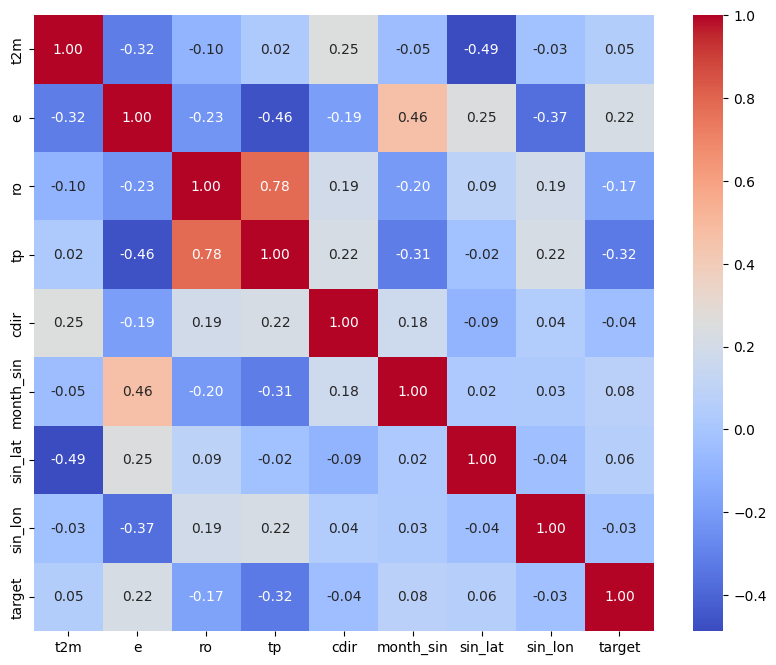

In [35]:
# Set the figure size (width, height) in inches
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(TrainData.corr(), annot=True, cmap='coolwarm', fmt=".2f")

# Show the plot
plt.show()

In [4]:
Xtr, ytr = TrainData.drop('target', axis=1), TrainData['target']

In [5]:
ValidData = pd.read_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/ValidDataV1.csv')
ValidData.columns = ValidData.columns.map(str.lower)  
ValidData.drop(['cos_lat', 'cos_lon', 'month_cos'], axis=1, inplace=True)
# ValidData.drop(['t2m_lag2', 'e_lag2', 'ro_lag2', 'tp_lag2', 'cdir_lag2', 't2m', 'e', 'ro', 'tp', 'cdir'], axis=1, inplace=True)
ValidData.head()

,t2m,e,ro,tp,cdir,month_sin,sin_lat,sin_lon,target
0,-4.179373,1.797502,-0.380768,-0.487673,-2.002652,0.5,0.601815,0.964787,0.0
1,-3.985594,1.719011,-0.380768,-0.548776,-2.002652,0.5,0.601815,0.967046,0.0
2,-4.131239,1.807260,-0.361480,-0.353827,-2.009950,0.5,0.598325,0.961262,0.0
3,-4.273333,1.817867,-0.374091,-0.314910,-1.997483,0.5,0.598325,0.962455,0.0
4,-4.227863,1.816594,-0.380768,-0.342734,-1.984103,0.5,0.598325,0.963630,0.0


In [6]:
Xval, yval = ValidData.drop('target', axis=1), ValidData['target']

In [8]:
TestData = pd.read_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/TestDataV1.csv')
TestData.columns = TestData.columns.map(str.lower)    
TestData.drop(['cos_lat', 'cos_lon', 'month_cos'], axis=1, inplace=True)
# TestData.drop(['t2m_lag1', 'e_lag1', 'ro_lag1', 'tp_lag1', 'cdir_lag1', 't2m', 'e', 'ro', 'tp', 'cdir'], axis=1, inplace=True)
TestData.head()

,t2m,e,ro,tp,cdir,month_sin,sin_lat,sin_lon,target
0,-4.289212,1.813545,-0.380768,-0.518770,-1.951566,0.5,0.601815,0.964787,1.0
1,-4.048542,1.787240,-0.380273,-0.546049,-1.962057,0.5,0.601815,0.967046,0.0
2,-4.257419,1.815666,-0.367909,-0.482035,-1.941075,0.5,0.598325,0.961262,1.0
3,-4.343208,1.819484,-0.376317,-0.441663,-1.934082,0.5,0.598325,0.962455,2.0
4,-4.332551,1.819060,-0.380768,-0.436571,-1.926480,0.5,0.598325,0.963630,2.0


In [9]:
Xte, yte = TestData.drop('target', axis=1), TestData['target']

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score 

In [43]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    # 'SVM': SVC(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
    'MLP': MLPClassifier(random_state=42, max_iter=500),
    'KNN': KNeighborsClassifier()
}

In [32]:
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xval)
    y_proba = model.predict_proba(Xval)[:, 1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(yval, y_pred)
    f1 = f1_score(yval, y_pred, average='macro')
    # roc_auc = roc_auc_score(yval, y_proba, multi_class='ovr', average='macro') if y_proba is not None else 'N/A'
    kappa = cohen_kappa_score(yval, y_pred)
    MCC = matthews_corrcoef(yval, y_pred)
    balanced_acc = balanced_accuracy_score(yval, y_pred)
    
    results[name] = {
        'accuracy': acc,
        'f1_score': f1,
        # 'roc_auc': roc_auc,
        'kappa': kappa,
        'MCC': MCC,
        'balanced_accuracy': balanced_acc
    }
    print(f"{name} - Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, Kappa: {kappa:.4f}, MCC: {MCC:.4f}, Balanced Accuracy: {balanced_acc:.4f}")

Training Logistic Regression...
Logistic Regression - Accuracy: 0.2839, F1 Score: 0.1526, Kappa: 0.0102, MCC: 0.0124, Balanced Accuracy: 0.1971
Training Random Forest...
Random Forest - Accuracy: 0.4395, F1 Score: 0.2288, Kappa: 0.0488, MCC: 0.0500, Balanced Accuracy: 0.2442
Training XGBoost...
XGBoost - Accuracy: 0.3549, F1 Score: 0.1984, Kappa: 0.0263, MCC: 0.0283, Balanced Accuracy: 0.2272


In [ ]:
# Display results in a DataFrame for better visualization
results_df = pd.DataFrame(results).T
print("\nModel Performance Summary:")
print(results_df.sort_values(by='accuracy', ascending=False))   

# save results to csv
results_df.to_csv(r'Results/model_performance_summary_v1.csv', index=True)


Model Performance Summary:
                     accuracy  f1_score     kappa       MCC  balanced_accuracy
Random Forest        0.657891  0.419960  0.389760  0.394514           0.448323
LightGBM             0.575085  0.335415  0.281394  0.289376           0.386808
XGBoost              0.559009  0.334606  0.269606  0.278961           0.392348
CatBoost             0.513334  0.301299  0.232088  0.245056           0.369732
KNN                  0.435857  0.266906  0.156864  0.171405           0.311355
Logistic Regression  0.414055  0.238392  0.139152  0.155802           0.283432
MLP                  0.332659  0.202657  0.097329  0.116246           0.275378


# Hyperparamter Tuning

## For Random Forest using RandomizedSearchCV

In [9]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define a targeted, efficient search space
param_distributions = {
    'n_estimators': [100, 200], # Keep trees lower to save time
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt'], # Usually best for classification
    'bootstrap': [True] 
}

# n_iter=10 means total time will be approx (10 iterations * 3 folds * 5 mins) / cores
# If you have 4+ cores, this should finish in roughly 15-30 minutes.
search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=10, 
    cv=3, 
    n_jobs=-1, # CRITICAL: This uses all your CPU cores in parallel
    verbose=2,
    scoring='f1_macro'
)

search.fit(Xtr, ytr.ravel())

print(f"Best Score: {search.best_score_}")
print(f"Best Params: {search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 2.8min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 2.8min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 2.8min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_split=2, n_estimators=100; total time= 3.8min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 3.9min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 4.0min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 4.0min
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_split=10, n_estimators=100; total time= 4.0min
[CV]

In [11]:
import joblib
import json

# 1. Save the actual model
joblib.dump(search.best_estimator_, r'Results/random_forest_spei_model.pkl')

# 2. Save the best parameters as a JSON file for future reference
with open(r'Results/best_params.json', 'w') as f:
    json.dump(search.best_params_, f)

print("Model and parameters saved successfully.")

Model and parameters saved successfully.


In [23]:
import joblib

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

# ==========================================================
# Load Model
# ==========================================================
loaded_model = joblib.load(
    r'Results/random_forest_spei_model.pkl'
)

# ==========================================================
# Predict Validation Set
# ==========================================================
y_valid_pred = loaded_model.predict(Xval)

# ==========================================================
# Calculate Metrics
# ==========================================================
acc = accuracy_score(yval, y_valid_pred)

f1 = f1_score(
    yval,
    y_valid_pred,
    average='macro'
)

balanced_acc = balanced_accuracy_score(
    yval,
    y_valid_pred
)

kappa = cohen_kappa_score(
    yval,
    y_valid_pred
)

MCC = matthews_corrcoef(
    yval,
    y_valid_pred
)

# ==========================================================
# Store Results
# ==========================================================
metrics = {
    'accuracy': acc,
    'f1_score': f1,
    'kappa': kappa,
    'MCC': MCC,
    'balanced_accuracy': balanced_acc
}

# ==========================================================
# Print Results
# ==========================================================
print("\n--- Validation Set Performance ---")

for metric, value in metrics.items():
    print(f"{metric:20s}: {value:.4f}")

# ==========================================================
# Classification Report
# ==========================================================
print("\nDetailed Classification Report:")
print(
    classification_report(
        yval,
        y_valid_pred,
        target_names=[
            'Non-drought',
            'Mild',
            'Moderate',
            'Severe',
            'Extreme'
        ]
    )
)

# ==========================================================
# Confusion Matrix
# ==========================================================
print("\nConfusion Matrix:")
print(confusion_matrix(yval, y_valid_pred))


--- Validation Set Performance ---
accuracy            : 0.6999
f1_score            : 0.4868
kappa               : 0.4712
MCC                 : 0.4785
balanced_accuracy   : 0.5281

Detailed Classification Report:
              precision    recall  f1-score   support

 Non-drought       0.94      0.80      0.86    778320
        Mild       0.40      0.56      0.47    195874
    Moderate       0.41      0.44      0.42    121735
      Severe       0.36      0.45      0.40     54981
     Extreme       0.22      0.39      0.28     18370

    accuracy                           0.70   1169280
   macro avg       0.46      0.53      0.49   1169280
weighted avg       0.75      0.70      0.72   1169280


Confusion Matrix:
[[623609 119463  21323   7700   6225]
 [ 32540 109607  37882  10638   5207]
 [  7290  34345  53221  19975   6904]
 [  1637   6663  14297  24796   7588]
 [   546   1398   2568   6662   7196]]


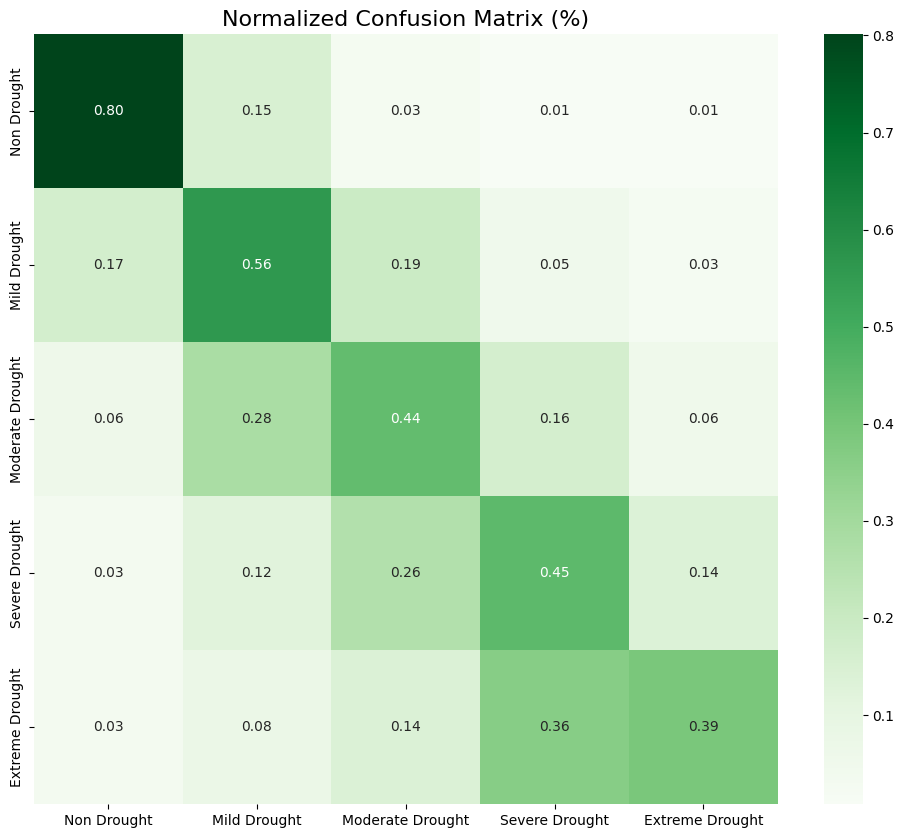

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Define your class labels (matching your 9-category logic)
class_names = [
     
    'Non Drought', 'Mild Drought', 'Moderate Drought', 'Severe Drought', 'Extreme Drought'
]

# 2. Generate the confusion matrix
# Replace 'y_test' and 'y_pred' with your actual test labels and model predictions
cm = confusion_matrix(yval, y_valid_pred)

# Compute normalized matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Normalized Confusion Matrix (%)', fontsize=16)
plt.show()

## CatBoost Hypertuning

In [17]:
from catboost import CatBoostClassifier

# 1. Initialize the model with GPU support
cat_model_gpu = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type='GPU',          # Tells CatBoost to use the GPU
    devices='0',              # Uses the first GPU (index 0)
    random_seed=42,
    verbose=False
)

# 2. Define the parameter grid
# Note: 'depth' on GPU is limited to 16, but 6-10 is best for your data
param_grid = {
    'learning_rate': [0.03, 0.1],
    'depth': [6, 8, 10],
    'l2_leaf_reg': [3, 5, 7],
    'iterations': [1000, 2000],
    'random_strength': [1, 2] # Helps with stability on GPU
}

# 3. Run the search
# With a GPU, you can afford more iterations (n_iter)
random_search_results = cat_model_gpu.randomized_search(
    param_grid,
    X=Xtr,
    y=ytr.ravel(),
    cv=3,
    n_iter=20, 
    # plot=True
)

print("Best parameters:", random_search_results['params'])

bestTest = 0.5720854418
bestIteration = 996
0:	loss: 0.5720854	best: 0.5720854 (0)	total: 15.8s	remaining: 5m
bestTest = 0.5706784001
bestIteration = 999
1:	loss: 0.5706784	best: 0.5720854 (0)	total: 31.3s	remaining: 4m 41s
bestTest = 0.5427563945
bestIteration = 1999
2:	loss: 0.5427564	best: 0.5720854 (0)	total: 1m 2s	remaining: 5m 54s
bestTest = 0.5720854418
bestIteration = 996
3:	loss: 0.5720854	best: 0.5720854 (0)	total: 1m 18s	remaining: 5m 13s
bestTest = 0.6074508008
bestIteration = 1999
4:	loss: 0.6074508	best: 0.6074508 (4)	total: 1m 49s	remaining: 5m 29s
bestTest = 0.5490943651
bestIteration = 996
5:	loss: 0.5490944	best: 0.6074508 (4)	total: 2m 13s	remaining: 5m 10s
bestTest = 0.6138793667
bestIteration = 998
6:	loss: 0.6138794	best: 0.6138794 (6)	total: 2m 36s	remaining: 4m 51s
bestTest = 0.5901996919
bestIteration = 1996
7:	loss: 0.5901997	best: 0.6138794 (6)	total: 3m 23s	remaining: 5m 5s
bestTest = 0.5881477054
bestIteration = 1999
8:	loss: 0.5881477	best: 0.6138794 (6)	t

In [18]:
# Save the model
cat_model_gpu.save_model(r'Results/catboost_spei_model.cbm')

# Load the model
from catboost import CatBoostClassifier
loaded_cat = CatBoostClassifier()
loaded_cat.load_model(r'Results/catboost_spei_model.cbm')

# Predict on validation data
y_valid_pred = loaded_cat.predict(Xval)

# 3. Calculate and display performance metrics
print("--- Validation Set Performance ---")
print(f"Accuracy: {accuracy_score(yval, y_valid_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(yval, y_valid_pred):.4f}")
print(f"F1-Score (Macro): {f1_score(yval, y_valid_pred, average='macro'):.4f}")

--- Validation Set Performance ---
Accuracy: 0.7088
Balanced Accuracy: 0.5365
F1-Score (Macro): 0.4954


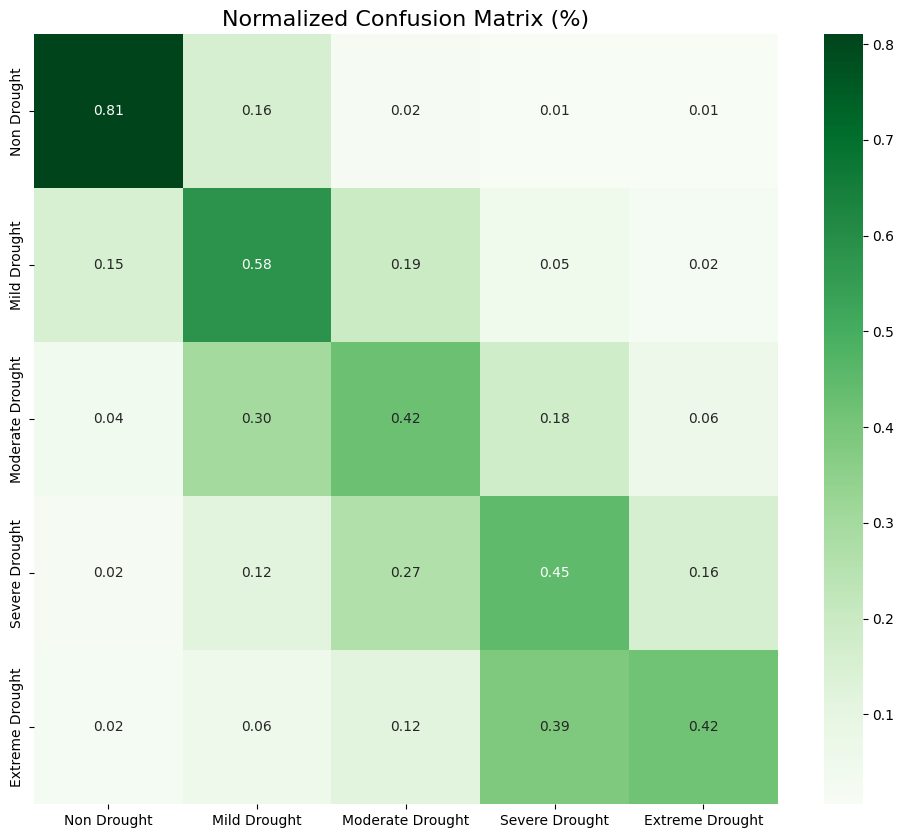

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Define your class labels (matching your 9-category logic)
class_names = [
     
    'Non Drought', 'Mild Drought', 'Moderate Drought', 'Severe Drought', 'Extreme Drought'
]

# 2. Generate the confusion matrix
# Replace 'y_test' and 'y_pred' with your actual test labels and model predictions
cm = confusion_matrix(yval, y_valid_pred)

# Compute normalized matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Normalized Confusion Matrix (%)', fontsize=16)
plt.show()

## XGBoost Hypertuning

In [31]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    # Narrowing down around your 500/0.05 baseline
    'n_estimators': [400, 500, 600],
    'learning_rate': [0.03, 0.05, 0.07],
    
    # Keeping your depth and regularization stable
    'max_depth': [8, 10],
    'min_child_weight': [3, 5],
    'gamma': [0.1, 0.2],
    
    # Fixed parameters from your manual success
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0.1],
    'reg_lambda': [1.0]
}

# Run the grid search using these centered values
grid_search = GridSearchCV(
    XGBClassifier(tree_method='hist', device='cuda', random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(Xtr, ytr.ravel())

Fitting 3 folds for each of 72 candidates, totalling 216 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'gamma': [0.1, 0.2], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [8, 10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [32]:
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.03, 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}
Best Score: 0.5604781893841803


In [33]:
import joblib
import json

# 1. Save the best model (the booster and its weights)
joblib.dump(grid_search.best_estimator_, r'Results/xgb_spei_best_model.pkl')

# 2. Save the best parameters to a JSON file for documentation
with open(r'Results/xgb_best_params.json', 'w') as f:
    json.dump(grid_search.best_params_, f)

print("XGBoost model and best parameters saved successfully.")

XGBoost model and best parameters saved successfully.


In [25]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

# ==========================================================
# Load Model
# ==========================================================
loaded_xgb = joblib.load(
    r'Results/xgb_spei_best_model.pkl'
)

# ==========================================================
# Predict Validation Set
# ==========================================================
y_valid_pred = loaded_xgb.predict(Xval)

# ==========================================================
# Calculate Metrics
# ==========================================================
acc = accuracy_score(yval, y_valid_pred)

f1 = f1_score(
    yval,
    y_valid_pred,
    average='macro'
)

balanced_acc = balanced_accuracy_score(
    yval,
    y_valid_pred
)

kappa = cohen_kappa_score(
    yval,
    y_valid_pred
)

MCC = matthews_corrcoef(
    yval,
    y_valid_pred
)

# ==========================================================
# Store Results
# ==========================================================
metrics = {
    'accuracy': acc,
    'f1_score': f1,
    'kappa': kappa,
    'MCC': MCC,
    'balanced_accuracy': balanced_acc
}

# ==========================================================
# Print Metrics
# ==========================================================
print("\n--- XGBoost Validation Performance ---")

for metric, value in metrics.items():
    print(f"{metric:20s}: {value:.4f}")

# ==========================================================
# Save Metrics
# ==========================================================
results_df = pd.DataFrame([metrics])

results_df.to_csv(
    "Results/XGBoost_Validation_Metrics.csv",
    index=False
)

# ==========================================================
# Classification Report
# ==========================================================
print("\nDetailed Classification Report:\n")

print(
    classification_report(
        yval,
        y_valid_pred,
        target_names=[
            'Non-drought',
            'Mild',
            'Moderate',
            'Severe',
            'Extreme'
        ]
    )
)



--- XGBoost Validation Performance ---
accuracy            : 0.6538
f1_score            : 0.4106
kappa               : 0.3901
MCC                 : 0.3968
balanced_accuracy   : 0.4578

Detailed Classification Report:

              precision    recall  f1-score   support

 Non-drought       0.91      0.78      0.84    778320
        Mild       0.35      0.49      0.40    195874
    Moderate       0.36      0.26      0.30    121735
      Severe       0.27      0.40      0.32     54981
     Extreme       0.12      0.36      0.18     18370

    accuracy                           0.65   1169280
   macro avg       0.40      0.46      0.41   1169280
weighted avg       0.72      0.65      0.68   1169280



In [23]:
from xgboost import XGBClassifier

model = XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        tree_method='hist',
        device='cuda',
        # eval_metric='mlogloss'
    )
model.fit(Xtr, ytr.ravel())
y_valid_pred = model.predict(Xval)

# 3. Calculate and display performance metrics
print("--- Validation Set Performance ---")
print(f"Accuracy: {accuracy_score(yval, y_valid_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(yval, y_valid_pred):.4f}")
print(f"F1-Score (Macro): {f1_score(yval, y_valid_pred, average='macro'):.4f}")

--- Validation Set Performance ---
Accuracy: 0.6797
Balanced Accuracy: 0.4900
F1-Score (Macro): 0.4454


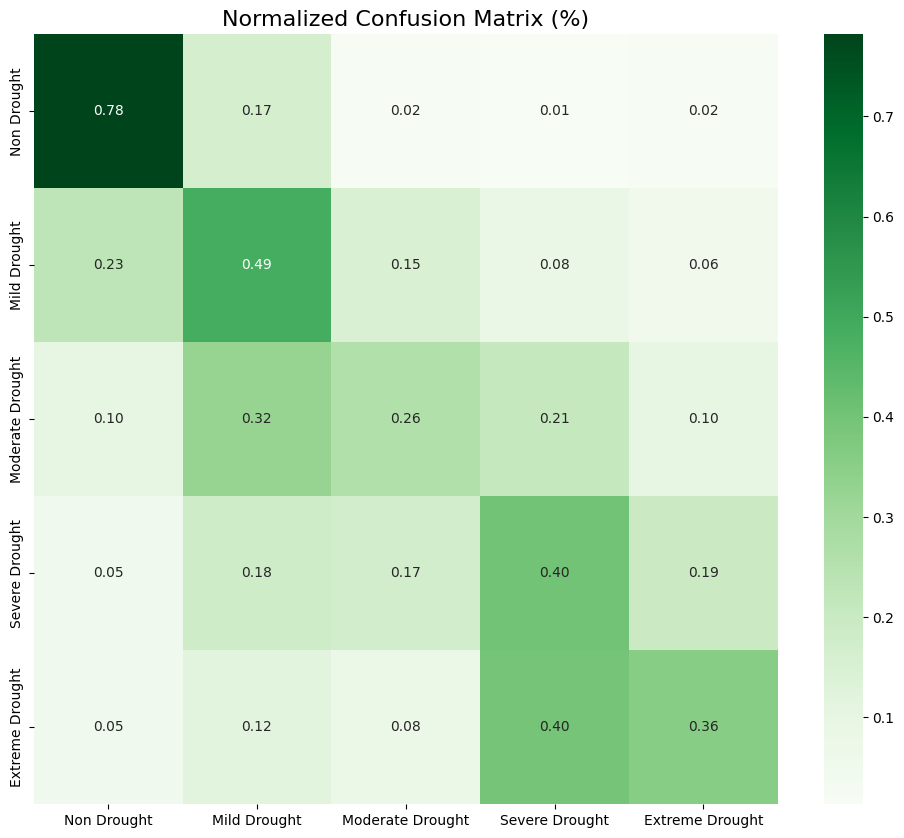

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Define your class labels (matching your 9-category logic)
class_names = [
     
    'Non Drought', 'Mild Drought', 'Moderate Drought', 'Severe Drought', 'Extreme Drought'
]

# 2. Generate the confusion matrix
# Replace 'y_test' and 'y_pred' with your actual test labels and model predictions
cm = confusion_matrix(yval, y_valid_pred)

# Compute normalized matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Normalized Confusion Matrix (%)', fontsize=16)
plt.show()

## hyperparameter tuned LGB

In [ ]:
# ============================================================
# LightGBM Hyperparameter Tuning
# ============================================================
import joblib
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
cohen_kappa_score, matthews_corrcoef,
confusion_matrix, classification_report)



In [ ]:
# ------------------------------------------------------------
# Step 1: Define Search Space
# ------------------------------------------------------------
param_distributions = {
# Core boosting parameters
'n_estimators': [500, 1000, 1500, 2000],
'learning_rate': [0.01, 0.03, 0.05, 0.1],
# Tree structure — leaf-wise growth (LightGBM default)
'num_leaves': [31, 63, 127, 255], # main complexity control in LightGBM
'max_depth': [-1, 6, 8, 10], # -1 means no limit (use num_leaves ins
'min_child_samples':[20, 50, 100], # min data in a leaf — controls overfit
# Regularization
'reg_alpha': [0.0, 0.1, 0.5, 1.0], # L1
'reg_lambda': [0.0, 0.1, 1.0, 5.0], # L2
# Sampling — prevents overfitting, speeds up training
'subsample': [0.6, 0.7, 0.8, 1.0],
'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
'subsample_freq': [1], # required for subsample < 1.0 to take
}


In [ ]:
# ------------------------------------------------------------
# Step 2: RandomizedSearchCV
# ------------------------------------------------------------
lgb_base = LGBMClassifier(
objective='multiclass',
num_class=5,
boosting_type='gbdt', # standard gradient boosting decision tree
device='gpu', # GPU acceleration (consistent with your XGBoost setup
random_state=42,
n_jobs=-1,
verbose=-1 # suppress LightGBM training logs
)
lgb_search = RandomizedSearchCV(
estimator=lgb_base,
param_distributions=param_distributions,
n_iter=30, # 30 iterations × 3 folds = 90 fits
cv=3,
scoring='f1_macro', # consistent with RF and XGBoost tuning
n_jobs=-1,
random_state=42,
verbose=2,
refit=True # refit best model on full training data
)
print("Starting LightGBM RandomizedSearchCV...")
print(f"Total fits: {30 * 3} (30 iterations × 3 folds)\n")
lgb_search.fit(
Xtr, ytr.ravel(),
# Early stopping on a small eval set to prevent overfitting per fold
eval_set=[(Xval, yval.ravel())],
callbacks=[
__import__('lightgbm').early_stopping(stopping_rounds=50, verbose=False),
__import__('lightgbm').log_evaluation(period=-1)
]
)
print(f"\nBest CV F1-Macro Score : {lgb_search.best_score_:.4f}")
print(f"Best Parameters : {lgb_search.best_params_}")
# ------------------------------------------------------------
# Step 3: Save Model and Parameters
# ------------------------------------------------------------
joblib.dump(lgb_search.best_estimator_, r'Results/lgb_spei_best_model.pkl')
with open(r'Results/lgb_best_params.json', 'w') as f:
json.dump(lgb_search.best_params_, f, indent=4)
print("\nLightGBM model and best parameters saved successfully.")


In [28]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

# ==========================================================
# Load Model
# ==========================================================
loaded_lgb = joblib.load(
    r'Results/lgb_spei_best_model.pkl'
)

# ==========================================================
# Predict Validation Set
# ==========================================================
y_valid_pred = loaded_lgb.predict(Xval)

# ==========================================================
# Calculate Metrics
# ==========================================================
acc = accuracy_score(yval, y_valid_pred)

f1 = f1_score(
    yval,
    y_valid_pred,
    average='macro'
)

balanced_acc = balanced_accuracy_score(
    yval,
    y_valid_pred
)

kappa = cohen_kappa_score(
    yval,
    y_valid_pred
)

MCC = matthews_corrcoef(
    yval,
    y_valid_pred
)

# ==========================================================
# Store Results
# ==========================================================
metrics = {
    'accuracy': acc,
    'f1_score': f1,
    'kappa': kappa,
    'MCC': MCC,
    'balanced_accuracy': balanced_acc
}

# ==========================================================
# Print Metrics
# ==========================================================
print("\n--- XGBoost Validation Performance ---")

for metric, value in metrics.items():
    print(f"{metric:20s}: {value:.4f}")

# ==========================================================
# Save Metrics
# ==========================================================
results_df = pd.DataFrame([metrics])

results_df.to_csv(
    "Results/LGB_Validation_Metrics.csv",
    index=False
)

# ==========================================================
# Classification Report
# ==========================================================
print("\nDetailed Classification Report:\n")

print(
    classification_report(
        yval,
        y_valid_pred,
        target_names=[
            'Non-drought',
            'Mild',
            'Moderate',
            'Severe',
            'Extreme'
        ]
    )
)



--- XGBoost Validation Performance ---
accuracy            : 0.7308
f1_score            : 0.5250
kappa               : 0.5207
MCC                 : 0.5279
balanced_accuracy   : 0.5630

Detailed Classification Report:

              precision    recall  f1-score   support

 Non-drought       0.95      0.83      0.89    778320
        Mild       0.44      0.62      0.52    195874
    Moderate       0.45      0.44      0.44    121735
      Severe       0.37      0.47      0.41     54981
     Extreme       0.30      0.45      0.36     18370

    accuracy                           0.73   1169280
   macro avg       0.50      0.56      0.52   1169280
weighted avg       0.78      0.73      0.75   1169280



# Ensemble Prediction On Test Data

In [10]:
# ============================================================
# Weighted Soft Voting Ensemble: RF + LightGBM + XGBoost
# ============================================================
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             cohen_kappa_score, matthews_corrcoef,
                             confusion_matrix, classification_report)


In [11]:

# ------------------------------------------------------------
# Step 1: Load All Three Tuned Models
# ------------------------------------------------------------
loaded_rf  = joblib.load(r'Results/random_forest_spei_model.pkl')
loaded_lgb = joblib.load(r'Results/lgb_spei_best_model.pkl')
loaded_xgb = joblib.load(r'Results/xgb_spei_best_model.pkl')

print("All three models loaded successfully.")
print(f"  RF  : {loaded_rf.__class__.__name__}")
print(f"  LGB : {loaded_lgb.__class__.__name__}")
print(f"  XGB : {loaded_xgb.__class__.__name__}")


All three models loaded successfully.
  RF  : RandomForestClassifier
  LGB : LGBMClassifier
  XGB : XGBClassifier


In [15]:

# ------------------------------------------------------------
# Step 2: Compute Validation MCC for Each Model
#         MCC is used as weight — most robust metric for
#         imbalanced multi-class problems
# ------------------------------------------------------------
y_te_rf  = loaded_rf.predict(Xte)
y_te_lgb = np.array(loaded_lgb.predict(Xte)).ravel()
y_te_xgb = loaded_xgb.predict(Xte)

mcc_rf  = matthews_corrcoef(yte, y_te_rf)
mcc_lgb = matthews_corrcoef(yte, y_te_lgb)
mcc_xgb = matthews_corrcoef(yte, y_te_xgb)

print("\n--- Individual Model Validation MCC (used as ensemble weights) ---")
print(f"  RF  MCC : {mcc_rf:.4f}")
print(f"  LGB MCC : {mcc_lgb:.4f}")
print(f"  XGB MCC : {mcc_xgb:.4f}")

# Normalize to sum to 1
total_mcc  = mcc_rf + mcc_lgb + mcc_xgb
w_rf  = mcc_rf  / total_mcc
w_lgb = mcc_lgb / total_mcc
w_xgb = mcc_xgb / total_mcc

print(f"\n--- Normalized Ensemble Weights ---")
print(f"  RF  weight : {w_rf:.4f}")
print(f"  LGB weight : {w_lgb:.4f}")
print(f"  XGB weight : {w_xgb:.4f}")

# Save weights for manuscript reference
weights = {'RF': round(w_rf, 4), 'LightGBM': round(w_lgb, 4), 'XGBoost': round(w_xgb, 4)}
with open(r'Results/ensemble_weights.json', 'w') as f:
    json.dump(weights, f, indent=4)



--- Individual Model Validation MCC (used as ensemble weights) ---
  RF  MCC : 0.4034
  LGB MCC : 0.4721
  XGB MCC : 0.3478

--- Normalized Ensemble Weights ---
  RF  weight : 0.3298
  LGB weight : 0.3859
  XGB weight : 0.2843


In [16]:

# ------------------------------------------------------------
# Step 3: Weighted Soft Voting — Validation Set
#         Ensemble probability = weighted average of
#         individual model predicted probabilities
# ------------------------------------------------------------
def weighted_soft_vote(models_proba, weights):
    """
    Compute weighted average of predicted probabilities.

    Parameters:
    -----------
    models_proba : list of np.ndarray, each shape (n_samples, n_classes)
    weights      : list of floats, must sum to 1

    Returns:
    --------
    y_proba_ensemble : np.ndarray (n_samples, n_classes)
    y_pred_ensemble  : np.ndarray (n_samples,) — argmax class
    """
    weighted_proba = np.zeros_like(models_proba[0])
    for proba, w in zip(models_proba, weights):
        weighted_proba += w * proba
    return weighted_proba, np.argmax(weighted_proba, axis=1)


# --- Validation probabilities ---
proba_val_rf  = loaded_rf.predict_proba(Xval)               # (n, 5)
proba_val_lgb = loaded_lgb.predict_proba(Xval)              # (n, 5)
proba_val_xgb = loaded_xgb.predict_proba(Xval)              # (n, 5)

proba_ensemble_val, y_pred_ensemble_val = weighted_soft_vote(
    models_proba=[proba_val_rf, proba_val_lgb, proba_val_xgb],
    weights=[w_rf, w_lgb, w_xgb]
)


In [17]:

# ------------------------------------------------------------
# Step 4: Validation Set Performance
# ------------------------------------------------------------
class_names = ['Non Drought', 'Mild Drought', 'Moderate Drought',
               'Severe Drought', 'Extreme Drought']

print("\n" + "="*55)
print("  ENSEMBLE — Validation Set Performance")
print("="*55)
print(f"Accuracy          : {accuracy_score(yval, y_pred_ensemble_val):.4f}")
print(f"Balanced Accuracy : {balanced_accuracy_score(yval, y_pred_ensemble_val):.4f}")
print(f"F1-Score (Macro)  : {f1_score(yval, y_pred_ensemble_val, average='macro'):.4f}")
print(f"Cohen's Kappa     : {cohen_kappa_score(yval, y_pred_ensemble_val):.4f}")
print(f"MCC               : {matthews_corrcoef(yval, y_pred_ensemble_val):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(yval, y_pred_ensemble_val, target_names=class_names))



  ENSEMBLE — Validation Set Performance
Accuracy          : 0.7248
Balanced Accuracy : 0.5549
F1-Score (Macro)  : 0.5147
Cohen's Kappa     : 0.5098
MCC               : 0.5168

Detailed Classification Report:
                  precision    recall  f1-score   support

     Non Drought       0.95      0.82      0.88    778320
    Mild Drought       0.43      0.61      0.50    195874
Moderate Drought       0.45      0.44      0.44    121735
  Severe Drought       0.37      0.47      0.42     54981
 Extreme Drought       0.26      0.43      0.33     18370

        accuracy                           0.72   1169280
       macro avg       0.49      0.55      0.51   1169280
    weighted avg       0.77      0.72      0.74   1169280



In [18]:

# ------------------------------------------------------------
# Step 5: TEST SET Evaluation — Final reported results
# ------------------------------------------------------------
proba_test_rf  = loaded_rf.predict_proba(Xte)
proba_test_lgb = loaded_lgb.predict_proba(Xte)
proba_test_xgb = loaded_xgb.predict_proba(Xte)

proba_ensemble_test, y_pred_ensemble_test = weighted_soft_vote(
    models_proba=[proba_test_rf, proba_test_lgb, proba_test_xgb],
    weights=[w_rf, w_lgb, w_xgb]
)

print("\n" + "="*55)
print("  ENSEMBLE — Test Set Performance (2021–2024)")
print("="*55)
print(f"Accuracy          : {accuracy_score(yte, y_pred_ensemble_test):.4f}")
print(f"Balanced Accuracy : {balanced_accuracy_score(yte, y_pred_ensemble_test):.4f}")
print(f"F1-Score (Macro)  : {f1_score(yte, y_pred_ensemble_test, average='macro'):.4f}")
print(f"Cohen's Kappa     : {cohen_kappa_score(yte, y_pred_ensemble_test):.4f}")
print(f"MCC               : {matthews_corrcoef(yte, y_pred_ensemble_test):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(yte, y_pred_ensemble_test, target_names=class_names))



  ENSEMBLE — Test Set Performance (2021–2024)
Accuracy          : 0.7256
Balanced Accuracy : 0.4874
F1-Score (Macro)  : 0.4601
Cohen's Kappa     : 0.4420
MCC               : 0.4509

Detailed Classification Report:
                  precision    recall  f1-score   support

     Non Drought       0.95      0.83      0.88    164447
    Mild Drought       0.33      0.52      0.41     27095
Moderate Drought       0.32      0.37      0.34     16070
  Severe Drought       0.26      0.37      0.31      8785
 Extreme Drought       0.37      0.35      0.36      6323

        accuracy                           0.73    222720
       macro avg       0.45      0.49      0.46    222720
    weighted avg       0.78      0.73      0.75    222720



In [19]:

# ------------------------------------------------------------
# Step 6: Consolidated Results Table
#         All models (default → tuned → ensemble) on TEST set
# ------------------------------------------------------------
def get_metrics(y_true, y_pred, label):
    return {
        'Model':             label,
        'Accuracy':          round(accuracy_score(y_true, y_pred), 4),
        'F1 Macro':          round(f1_score(y_true, y_pred, average='macro'), 4),
        'Kappa':             round(cohen_kappa_score(y_true, y_pred), 4),
        'MCC':               round(matthews_corrcoef(y_true, y_pred), 4),
        'Balanced Accuracy': round(balanced_accuracy_score(y_true, y_pred), 4),
    }

# Individual model test predictions
y_test_rf  = loaded_rf.predict(Xte)
y_test_lgb = np.array(loaded_lgb.predict(Xte)).ravel()
y_test_xgb = loaded_xgb.predict(Xte)

consolidated = pd.DataFrame([
    get_metrics(yte, y_test_rf,             'Random Forest (Tuned)'),
    get_metrics(yte, y_test_lgb,            'LightGBM (Tuned)'),
    get_metrics(yte, y_test_xgb,            'XGBoost (Tuned)'),
    get_metrics(yte, y_pred_ensemble_test,  'Ensemble (RF+LGB+XGB)'),
]).set_index('Model')

print("\n--- Consolidated Test Set Results ---")
print(consolidated.to_string())
consolidated.to_csv(r'Results/consolidated_test_results.csv')



--- Consolidated Test Set Results ---
                       Accuracy  F1 Macro   Kappa     MCC  Balanced Accuracy
Model                                                                       
Random Forest (Tuned)    0.6974    0.4262  0.3940  0.4034             0.4566
LightGBM (Tuned)         0.7351    0.4757  0.4624  0.4721             0.5029
XGBoost (Tuned)          0.6693    0.3776  0.3392  0.3478             0.4090
Ensemble (RF+LGB+XGB)    0.7256    0.4601  0.4420  0.4509             0.4874


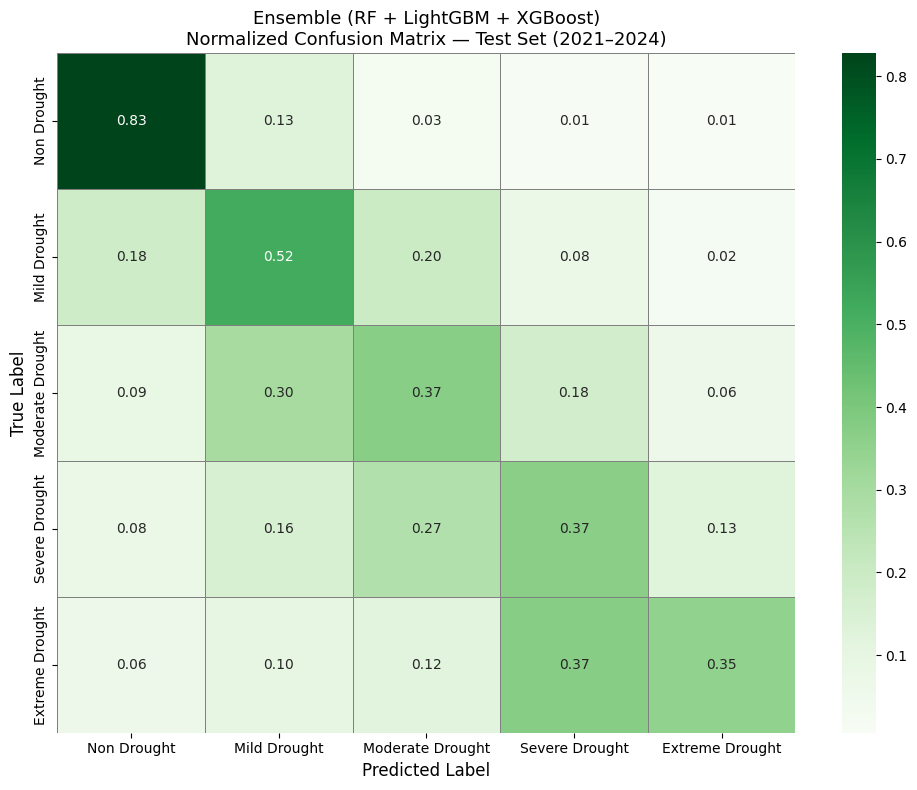

In [20]:

# ------------------------------------------------------------
# Step 7: Confusion Matrix — Ensemble on Test Set
# ------------------------------------------------------------
cm_test = confusion_matrix(yte, y_pred_ensemble_test)
cm_test_norm = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_test_norm, annot=True, fmt='.2f', cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5, linecolor='gray'
)
plt.title('Ensemble (RF + LightGBM + XGBoost)\nNormalized Confusion Matrix — Test Set (2021–2024)',
          fontsize=13)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(r'Results/ensemble_confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()


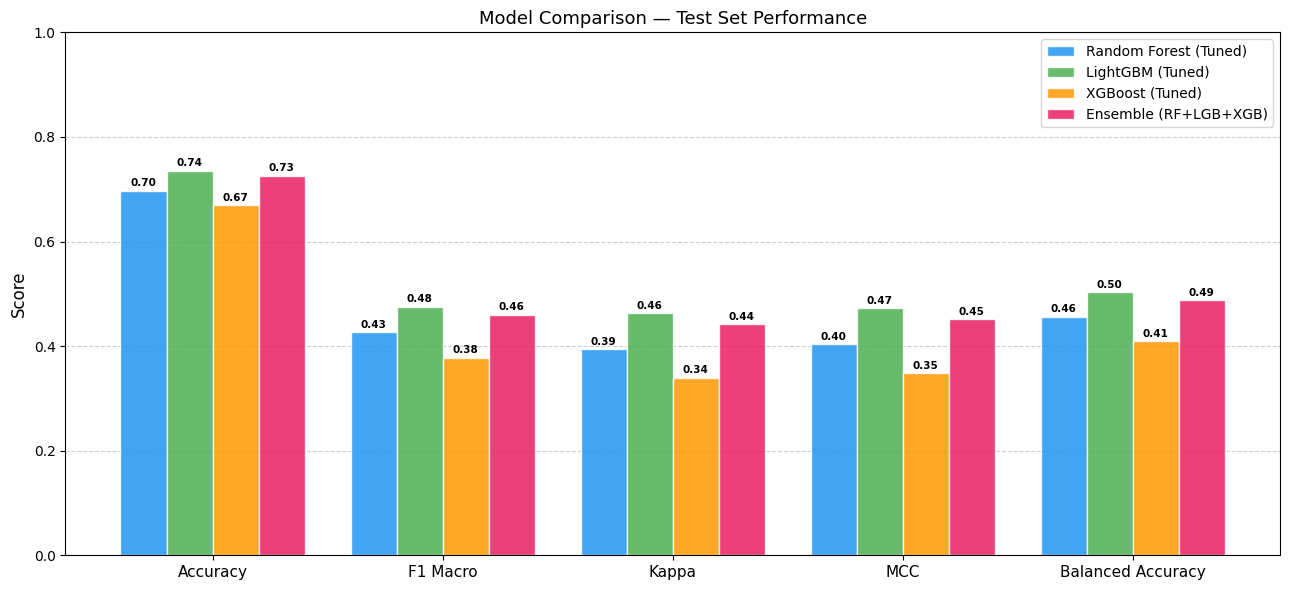

In [21]:

# ------------------------------------------------------------
# Step 8: Bar Chart — Model Comparison on Test Set
# ------------------------------------------------------------
metrics_to_plot = ['Accuracy', 'F1 Macro', 'Kappa', 'MCC', 'Balanced Accuracy']
x = np.arange(len(metrics_to_plot))
bar_width = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
labels = consolidated.index.tolist()

fig, ax = plt.subplots(figsize=(13, 6))
for i, (label, color) in enumerate(zip(labels, colors)):
    values = [consolidated.loc[label, m] for m in metrics_to_plot]
    bars = ax.bar(x + i * bar_width, values, bar_width,
                  label=label, color=color, alpha=0.85, edgecolor='white')
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')

ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Test Set Performance', fontsize=13)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10, loc='upper right')
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(r'Results/model_comparison_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:

# ------------------------------------------------------------
# Step 9: Save Ensemble Predictions for SHAP & Spatial Analysis
# ------------------------------------------------------------
# Save test predictions with coordinates for spatial mapping later
TestData_with_preds = TestData.copy()
TestData_with_preds['y_pred_ensemble'] = y_pred_ensemble_test
TestData_with_preds['y_true']          = np.array(yte).ravel()

# Save class probabilities for each drought class
for i, cls in enumerate(class_names):
    TestData_with_preds[f'proba_{cls.replace(" ", "_")}'] = proba_ensemble_test[:, i]

TestData_with_preds.to_csv(r'Results/test_predictions_ensemble.csv', index=False)
print("\nEnsemble predictions + probabilities saved to Results/test_predictions_ensemble.csv")
print("\nNext step → SHAP analysis on ensemble")


Ensemble predictions + probabilities saved to Results/test_predictions_ensemble.csv

Next step → SHAP analysis on ensemble
